# Time Series Analysis for Cluster 2

This notebook performs time series analysis on hourly demand data for cluster 2.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Import helper functions with reload capability
from importlib import reload
import timeseries_helpers
reload(timeseries_helpers)
from timeseries_helpers import (
    rolling_forecast_validation,
    in_sample_prediction,
    plot_predictions,
    print_performance_comparison,
    evaluate_model,
    # New fast evaluation functions
    dynamic_forecast_validation,
    fitted_in_sample_prediction,
    evaluate_fitted_model
)

In [4]:
# Load the hourly demand data
df = pd.read_csv('data/hourly_demand_2018_2019_complete.csv')
print(f"Data shape: {df.shape}")
df.head()

Data shape: (526110, 6)


,cluster,hour,pickups,dropoffs,year,total_demand
0,0.0,2018-01-01 00:00:00,3,2,2018,5
1,0.0,2018-01-01 01:00:00,1,5,2018,6
2,0.0,2018-01-01 02:00:00,4,1,2018,5
3,0.0,2018-01-01 03:00:00,0,1,2018,1
4,0.0,2018-01-01 04:00:00,0,0,2018,0


In [5]:
# Check columns and filter for 2018 data only
print("Columns in dataframe:", df.columns.tolist())

# Find the datetime column (could be 'datetime', 'date', 'timestamp', etc.)
datetime_col = 'hour'

df[datetime_col] = pd.to_datetime(df[datetime_col])
df_2018 = df[df[datetime_col].dt.year == 2018].copy()


print(f"2018 data shape: {df_2018.shape}")
df_2018.head()

Columns in dataframe: ['cluster', 'hour', 'pickups', 'dropoffs', 'year', 'total_demand']
2018 data shape: (262800, 6)


,cluster,hour,pickups,dropoffs,year,total_demand
0,0.0,2018-01-01 00:00:00,3,2,2018,5
1,0.0,2018-01-01 01:00:00,1,5,2018,6
2,0.0,2018-01-01 02:00:00,4,1,2018,5
3,0.0,2018-01-01 03:00:00,0,1,2018,1
4,0.0,2018-01-01 04:00:00,0,0,2018,0


## Load and Prepare Exogenous Variables

Loading weather data and creating exogenous features:
- Temperature and temperature squared
- Rain indicators (current and 1-hour lag)
- Weekend and holiday indicators

In [6]:
# Download NYC weather data
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aadimator/nyc-weather-2016-to-2022")
print("Path to dataset files:", path)

Path to dataset files: /Users/kristian/.cache/kagglehub/datasets/aadimator/nyc-weather-2016-to-2022/versions/1


In [7]:
# Load weather data
import os
weather_files = os.listdir(path)
print("Available files:", weather_files)

# Find the weather CSV file
weather_file = [f for f in weather_files if f.endswith('.csv')][0]
weather_df = pd.read_csv(os.path.join(path, weather_file))

print(f"\nWeather data shape: {weather_df.shape}")
print(f"Columns: {weather_df.columns.tolist()}")
weather_df.head()

Available files: ['NYC_Weather_2016_2022.csv']

Weather data shape: (59760, 10)
Columns: ['time', 'temperature_2m (°C)', 'precipitation (mm)', 'rain (mm)', 'cloudcover (%)', 'cloudcover_low (%)', 'cloudcover_mid (%)', 'cloudcover_high (%)', 'windspeed_10m (km/h)', 'winddirection_10m (°)']


,time,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
0,2016-01-01T00:00,7.6,0.0,0.0,69.0,53.0,0.0,72.0,10.0,296.0
1,2016-01-01T01:00,7.5,0.0,0.0,20.0,4.0,0.0,56.0,9.8,287.0
2,2016-01-01T02:00,7.1,0.0,0.0,32.0,3.0,0.0,99.0,9.7,285.0
3,2016-01-01T03:00,6.6,0.0,0.0,35.0,5.0,0.0,100.0,9.2,281.0
4,2016-01-01T04:00,6.3,0.0,0.0,34.0,4.0,0.0,100.0,9.1,279.0


In [8]:
# Load holidays data
holidays_df = pd.read_csv('data/holidays_2018_2019.csv')
print("Holidays data:")
print(holidays_df.head())

# Filter for 2018 only
holidays_df['date'] = pd.to_datetime(holidays_df['date'])
holidays_2018 = holidays_df[holidays_df['date'].dt.year == 2018].copy()
print(f"\n2018 holidays: {len(holidays_2018)} days")
print(holidays_2018)

Holidays data:
                         name        date    region         category  \
0              New Year's Day  2018-01-01  New York  Federal Holiday   
1  Martin Luther King Jr. Day  2018-01-15  New York  Federal Holiday   
2             Presidents' Day  2018-02-19  New York  Federal Holiday   
3                Memorial Day  2018-05-28  New York  Federal Holiday   
4            Independence Day  2018-07-04  New York  Federal Holiday   

                                     notes  
0  Closure of government offices and banks  
1                  Third Monday in January  
2           Washington's Birthday observed  
3                       Last Monday in May  
4                           Fourth of July  

2018 holidays: 11 days
                          name       date    region         category  \
0               New Year's Day 2018-01-01  New York  Federal Holiday   
1   Martin Luther King Jr. Day 2018-01-15  New York  Federal Holiday   
2              Presidents' Day 2018-02-19 

In [9]:
# Prepare weather data for 2018
# Parse datetime column (need to check actual column name first)
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'] if 'datetime' in weather_df.columns 
                                        else weather_df['time'] if 'time' in weather_df.columns 
                                        else weather_df.iloc[:, 0])

# Filter for 2018
weather_2018 = weather_df[weather_df['datetime'].dt.year == 2018].copy()

# Set datetime as index and sort
weather_2018 = weather_2018.set_index('datetime').sort_index()

# Resample to hourly (in case data is not hourly)
# We'll use forward fill for missing hours
weather_hourly = weather_2018.resample('H').ffill()

print(f"Weather 2018 shape: {weather_hourly.shape}")
print(f"Date range: {weather_hourly.index.min()} to {weather_hourly.index.max()}")
weather_hourly.head()

Weather 2018 shape: (8760, 10)
Date range: 2018-01-01 00:00:00 to 2018-12-31 23:00:00


,time,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
datetime,,,,,,,,,,
2018-01-01 00:00:00,2018-01-01T00:00,-11.1,0.0,0.0,0.0,0.0,0.0,0.0,9.4,302.0
2018-01-01 01:00:00,2018-01-01T01:00,-11.5,0.0,0.0,0.0,0.0,0.0,0.0,10.1,297.0
2018-01-01 02:00:00,2018-01-01T02:00,-11.8,0.0,0.0,0.0,0.0,0.0,0.0,12.3,302.0
2018-01-01 03:00:00,2018-01-01T03:00,-12.2,0.0,0.0,0.0,0.0,0.0,0.0,13.9,307.0
2018-01-01 04:00:00,2018-01-01T04:00,-12.2,0.0,0.0,0.0,0.0,0.0,0.0,14.3,309.0


In [10]:
# Create exogenous features dataframe with UNIQUE hourly timestamps for 2018
# Use pd.date_range to create a clean hourly index
hourly_index_2018 = pd.date_range(start='2018-01-01 00:00:00', 
                                   end='2018-12-31 23:00:00', 
                                   freq='H')

exog_features = pd.DataFrame(index=hourly_index_2018)

# 1. Temperature (find the temperature column in weather data)
temp_col = 'temperature_2m (°C)'

# Align weather data with demand data timestamps
exog_features['temp'] = weather_hourly[temp_col].reindex(exog_features.index, method='nearest')

# 2. Temperature squared
exog_features['temp_squared'] = exog_features['temp'] ** 2

# 3. Rain indicator (current hour)
precip_col = 'precipitation (mm)'

precip_data = weather_hourly[precip_col].reindex(exog_features.index, method='nearest')
exog_features['is_raining'] = (precip_data > 1.0).astype(int)  # More than 1mm

# 4. Rain lag (1 hour ago)
exog_features['rain_lag1'] = exog_features['is_raining'].shift(1).fillna(0).astype(int)

# 5. Weekend indicator
exog_features['is_weekend'] = exog_features.index.dayofweek.isin([5, 6]).astype(int)

# 6. Holiday indicator
holiday_dates = set(holidays_2018['date'].dt.date)
exog_features['is_holiday'] = [1 if d in holiday_dates else 0 for d in exog_features.index.date]

print(f"Exogenous features shape: {exog_features.shape}")
print(f"Date range: {exog_features.index.min()} to {exog_features.index.max()}")
print(f"\nFeature summary:")
print(exog_features.describe())
print(f"\nSample data:")
exog_features.head(30)

Exogenous features shape: (8760, 6)
Date range: 2018-01-01 00:00:00 to 2018-12-31 23:00:00

Feature summary:
              temp  temp_squared   is_raining    rain_lag1   is_weekend  \
count  8760.000000   8760.000000  8760.000000  8760.000000  8760.000000   
mean     12.755970    267.299113     0.052511     0.052397     0.284932   
std      10.227232    271.981979     0.223069     0.222840     0.451408   
min     -18.300000      0.000000     0.000000     0.000000     0.000000   
25%       4.375000     25.000000     0.000000     0.000000     0.000000   
50%      12.300000    156.250000     0.000000     0.000000     0.000000   
75%      21.800000    475.240000     0.000000     0.000000     1.000000   
max      34.500000   1190.250000     1.000000     1.000000     1.000000   

        is_holiday  
count  8760.000000  
mean      0.030137  
std       0.170974  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  

Sample data:


,temp,temp_squared,is_raining,rain_lag1,is_weekend,is_holiday
2018-01-01 00:00:00,-11.1,123.21,0,0,0,1
2018-01-01 01:00:00,-11.5,132.25,0,0,0,1
2018-01-01 02:00:00,-11.8,139.24,0,0,0,1
2018-01-01 03:00:00,-12.2,148.84,0,0,0,1
2018-01-01 04:00:00,-12.2,148.84,0,0,0,1
2018-01-01 05:00:00,-12.3,151.29,0,0,0,1
2018-01-01 06:00:00,-12.4,153.76,0,0,0,1
2018-01-01 07:00:00,-12.4,153.76,0,0,0,1
2018-01-01 08:00:00,-12.5,156.25,0,0,0,1
2018-01-01 09:00:00,-13.0,169.00,0,0,0,1


In [11]:
# Filter exogenous features for cluster 2 (same timestamps as cluster_2_data)
# After we create cluster_2_data, we'll align the exog features
# For now, let's save it for use later
print("Exogenous features created successfully!")
print(f"\nFeature correlations with each other:")
print(exog_features.corr())

Exogenous features created successfully!

Feature correlations with each other:
                  temp  temp_squared  is_raining  rain_lag1  is_weekend  \
temp          1.000000      0.918683    0.003195   0.002345   -0.011507   
temp_squared  0.918683      1.000000   -0.023713  -0.026561   -0.031147   
is_raining    0.003195     -0.023713    1.000000   0.702571    0.019197   
rain_lag1     0.002345     -0.026561    0.702571   1.000000    0.016135   
is_weekend   -0.011507     -0.031147    0.019197   0.016135    1.000000   
is_holiday   -0.076200     -0.026514   -0.029525  -0.029465   -0.111273   

              is_holiday  
temp           -0.076200  
temp_squared   -0.026514  
is_raining     -0.029525  
rain_lag1      -0.029465  
is_weekend     -0.111273  
is_holiday      1.000000  


In [12]:
# Filter for cluster 2 only
cluster_2_data = df_2018[df_2018['cluster'] == 2].copy()
print(f"Cluster 2 data shape: {cluster_2_data.shape}")
cluster_2_data.head()

Cluster 2 data shape: (8760, 6)


,cluster,hour,pickups,dropoffs,year,total_demand
35074,2.0,2018-01-01 00:00:00,15,4,2018,19
35075,2.0,2018-01-01 01:00:00,20,17,2018,37
35076,2.0,2018-01-01 02:00:00,8,8,2018,16
35077,2.0,2018-01-01 03:00:00,5,7,2018,12
35078,2.0,2018-01-01 04:00:00,4,0,2018,4


In [13]:
# Prepare time series data
# Assuming there's a datetime column - we'll need to set it as index
# Let's first check the columns
cluster_2_data.columns

Index(['cluster', 'hour', 'pickups', 'dropoffs', 'year', 'total_demand'], dtype='object')

In [14]:
# Set datetime as index and prepare time series
# Adjust the column name based on what's in the data
# if 'datetime' in cluster_2_data.columns:
#     cluster_2_data['datetime'] = pd.to_datetime(cluster_2_data['datetime'])
#     cluster_2_data = cluster_2_data.set_index('datetime')
# elif 'date' in cluster_2_data.columns:
#     cluster_2_data['date'] = pd.to_datetime(cluster_2_data['date'])
#     cluster_2_data = cluster_2_data.set_index('date')
cluster_2_data['hour'] = pd.to_datetime(cluster_2_data['hour'])
cluster_2_data = cluster_2_data.set_index('hour')
# Sort by index
cluster_2_data = cluster_2_data.sort_index()

# Get the pickups column (assuming it's named 'pickups')
ts_data = cluster_2_data['pickups']


print(f"Time series data shape: {ts_data.shape}")
ts_data.head()

Time series data shape: (8760,)


hour
2018-01-01 00:00:00    15
2018-01-01 01:00:00    20
2018-01-01 02:00:00     8
2018-01-01 03:00:00     5
2018-01-01 04:00:00     4
Name: pickups, dtype: int64

In [15]:
# Align exogenous features with cluster 2 time series
exog_cluster2 = exog_features.loc[ts_data.index]

print(f"Exogenous features for cluster 2: {exog_cluster2.shape}")
print(f"Time series data: {ts_data.shape}")
print(f"\nExogenous features preview:")
exog_cluster2.head()

Exogenous features for cluster 2: (8760, 6)
Time series data: (8760,)

Exogenous features preview:


,temp,temp_squared,is_raining,rain_lag1,is_weekend,is_holiday
hour,,,,,,
2018-01-01 00:00:00,-11.1,123.21,0,0,0,1
2018-01-01 01:00:00,-11.5,132.25,0,0,0,1
2018-01-01 02:00:00,-11.8,139.24,0,0,0,1
2018-01-01 03:00:00,-12.2,148.84,0,0,0,1
2018-01-01 04:00:00,-12.2,148.84,0,0,0,1


## Seasonal Decomposition

Using `seasonal_decompose` to break down the time series into trend, seasonal, and residual components.

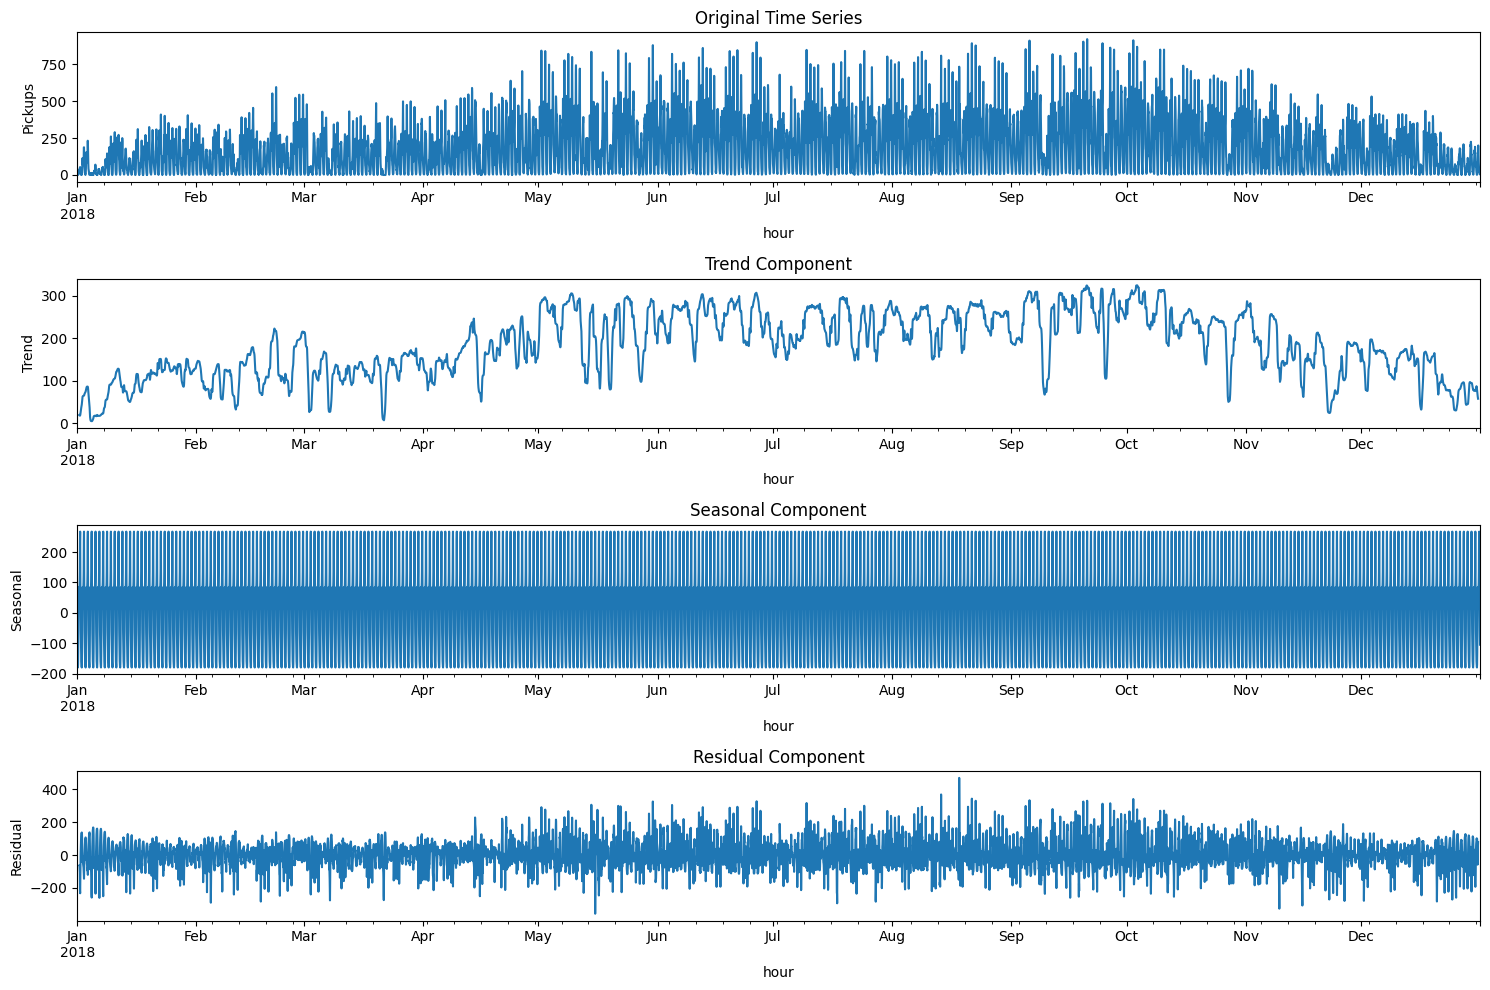

In [16]:
# Perform seasonal decomposition
# Using period=24 for hourly data (24 hours in a day)
# Adjust period if needed based on your data characteristics
decomposition = seasonal_decompose(ts_data, model='additive', period=24)

# Plot the decomposition
fig, axes = plt.subplots(4, 1, figsize=(15, 10))

# Original
ts_data.plot(ax=axes[0], title='Original Time Series')
axes[0].set_ylabel('Pickups')

# Trend
decomposition.trend.plot(ax=axes[1], title='Trend Component')
axes[1].set_ylabel('Trend')

# Seasonal
decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component')
axes[2].set_ylabel('Seasonal')

# Residual
decomposition.resid.plot(ax=axes[3], title='Residual Component')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.show()

## ARIMA Model Training

Training a dummy ARIMA(0,0,0) model as a baseline.
- Training data: January to October 2018
- Validation data: November and December 2018

In [17]:
# Split data into train (Jan-Oct) and validation (Nov-Dec)
train_ts = ts_data[ts_data.index.month <= 10]
val_ts = ts_data[ts_data.index.month >= 11]

print(f"Training data shape: {train_ts.shape}")
print(f"Training period: {train_ts.index.min()} to {train_ts.index.max()}")
print(f"\nValidation data shape: {val_ts.shape}")
print(f"Validation period: {val_ts.index.min()} to {val_ts.index.max()}")

# Train dummy ARIMA(0,0,0) model on training data
arima = ARIMA(train_ts, order=(0,0,0), enforce_invertibility=False, enforce_stationarity=False)
results = arima.fit()

# Display summary
results.summary()

Training data shape: (7296,)
Training period: 2018-01-01 00:00:00 to 2018-10-31 23:00:00

Validation data shape: (1464,)
Validation period: 2018-11-01 00:00:00 to 2018-12-31 23:00:00


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                pickups   No. Observations:                 7296
Model:                          ARIMA   Log Likelihood              -48180.796
Date:                Thu, 04 Dec 2025   AIC                          96365.592
Time:                        10:49:30   BIC                          96379.382
Sample:                    01-01-2018   HQIC                         96370.334
                         - 10-31-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        194.4425      2.661     73.073      0.000     189.227     199.658
sigma2       3.19e+04    575.730     55.407      0.000    3.08e+04     3.3e+04
===================================================================================
Ljung-Box (L1) (Q):                5781.34   Jarque-Bera (JB):              1426.99
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.33   Skew:                             1.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [18]:
# Split exogenous features into train and validation sets (aligned with train_ts and val_ts)
exog_train = exog_cluster2.loc[train_ts.index]
exog_val = exog_cluster2.loc[val_ts.index]

print(f"Training exog features: {exog_train.shape}")
print(f"Validation exog features: {exog_val.shape}")
print(f"\nTraining exog summary:")
print(exog_train.describe())

Training exog features: (7296, 6)
Validation exog features: (1464, 6)

Training exog summary:
              temp  temp_squared   is_raining    rain_lag1   is_weekend  \
count  7296.000000   7296.000000  7296.000000  7296.000000  7296.000000   
mean     14.264844    310.492482     0.049479     0.049479     0.282895   
std      10.345114    276.902941     0.216881     0.216881     0.450437   
min     -18.300000      0.000000     0.000000     0.000000     0.000000   
25%       5.700000     43.232500     0.000000     0.000000     0.000000   
50%      16.200000    262.440000     0.000000     0.000000     0.000000   
75%      22.900000    524.410000     0.000000     0.000000     1.000000   
max      34.500000   1190.250000     1.000000     1.000000     1.000000   

        is_holiday  
count  7296.000000  
mean      0.023026  
std       0.149997  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  


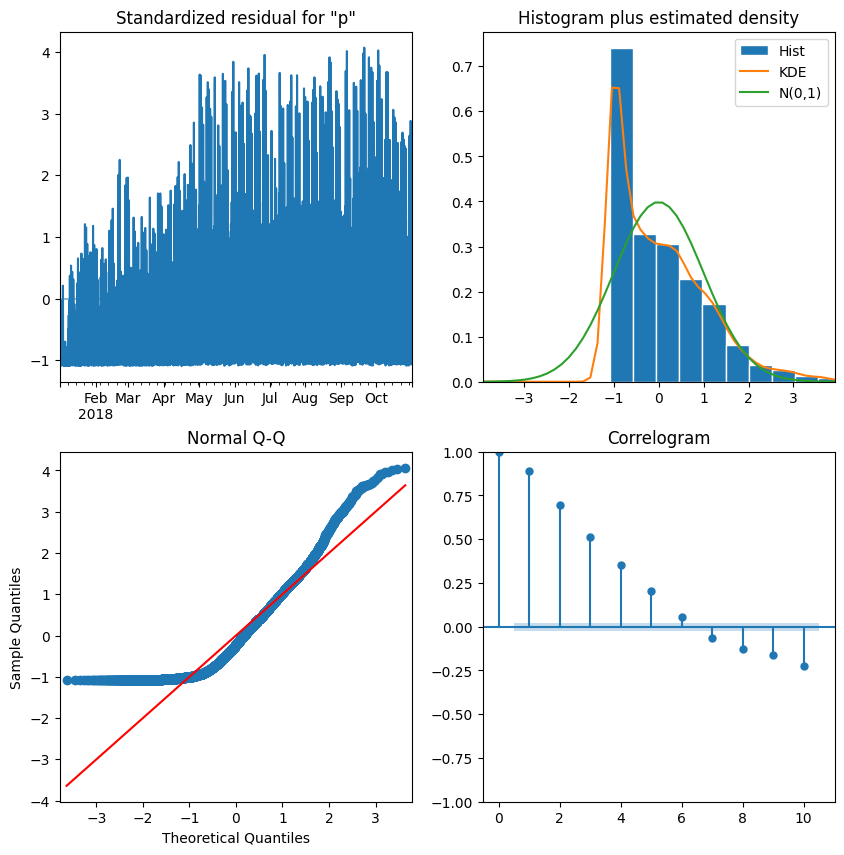

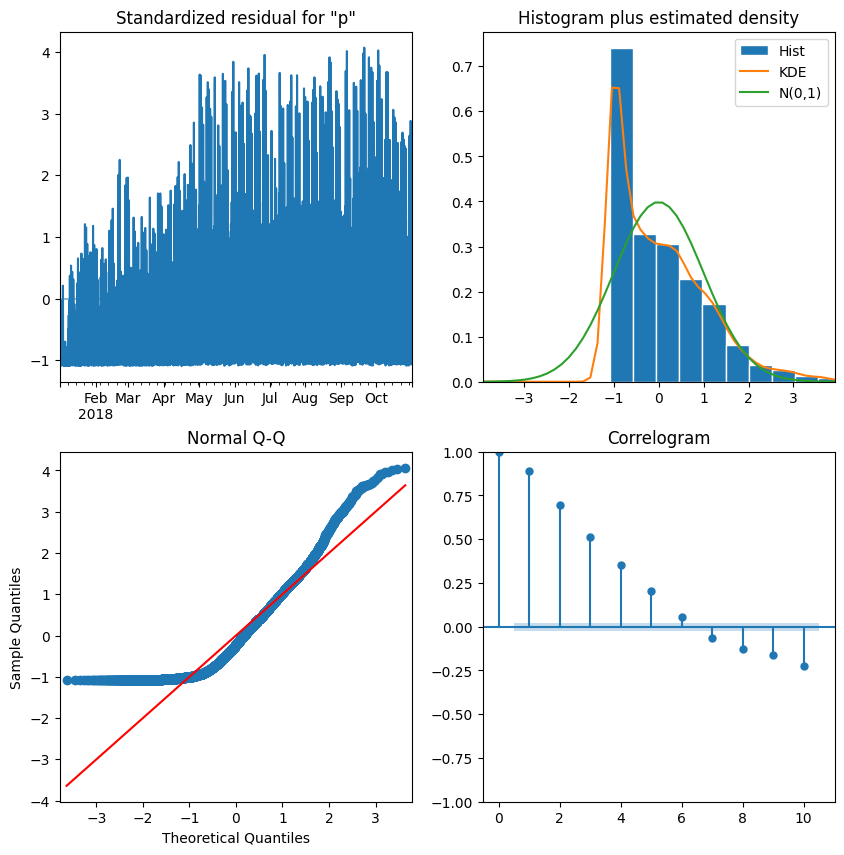

In [19]:
# # Display the model
# print("Model:", arima)
# print("\nFitted Results:", results)
results.plot_diagnostics(figsize = (10,10))

Evaluating ARIMA(0,0,0) Baseline...
  - Evaluating on training set...
  - Evaluating on validation set (rolling 24h forecast)...
  - Evaluating on validation set (rolling 24h forecast)...

ARIMA(0,0,0) Baseline - Performance Comparison

Metric               Training             Validation          
------------------------------------------------------------
MSE                  31932.80             18843.55            
RMSE                 178.70               137.27              
MAE                  145.88               117.57              

ℹ️  Note: Validation performance is better than training.
   This is unusual but can happen with small datasets.

ARIMA(0,0,0) Baseline - Performance Comparison

Metric               Training             Validation          
------------------------------------------------------------
MSE                  31932.80             18843.55            
RMSE                 178.70               137.27              
MAE                  145.88          

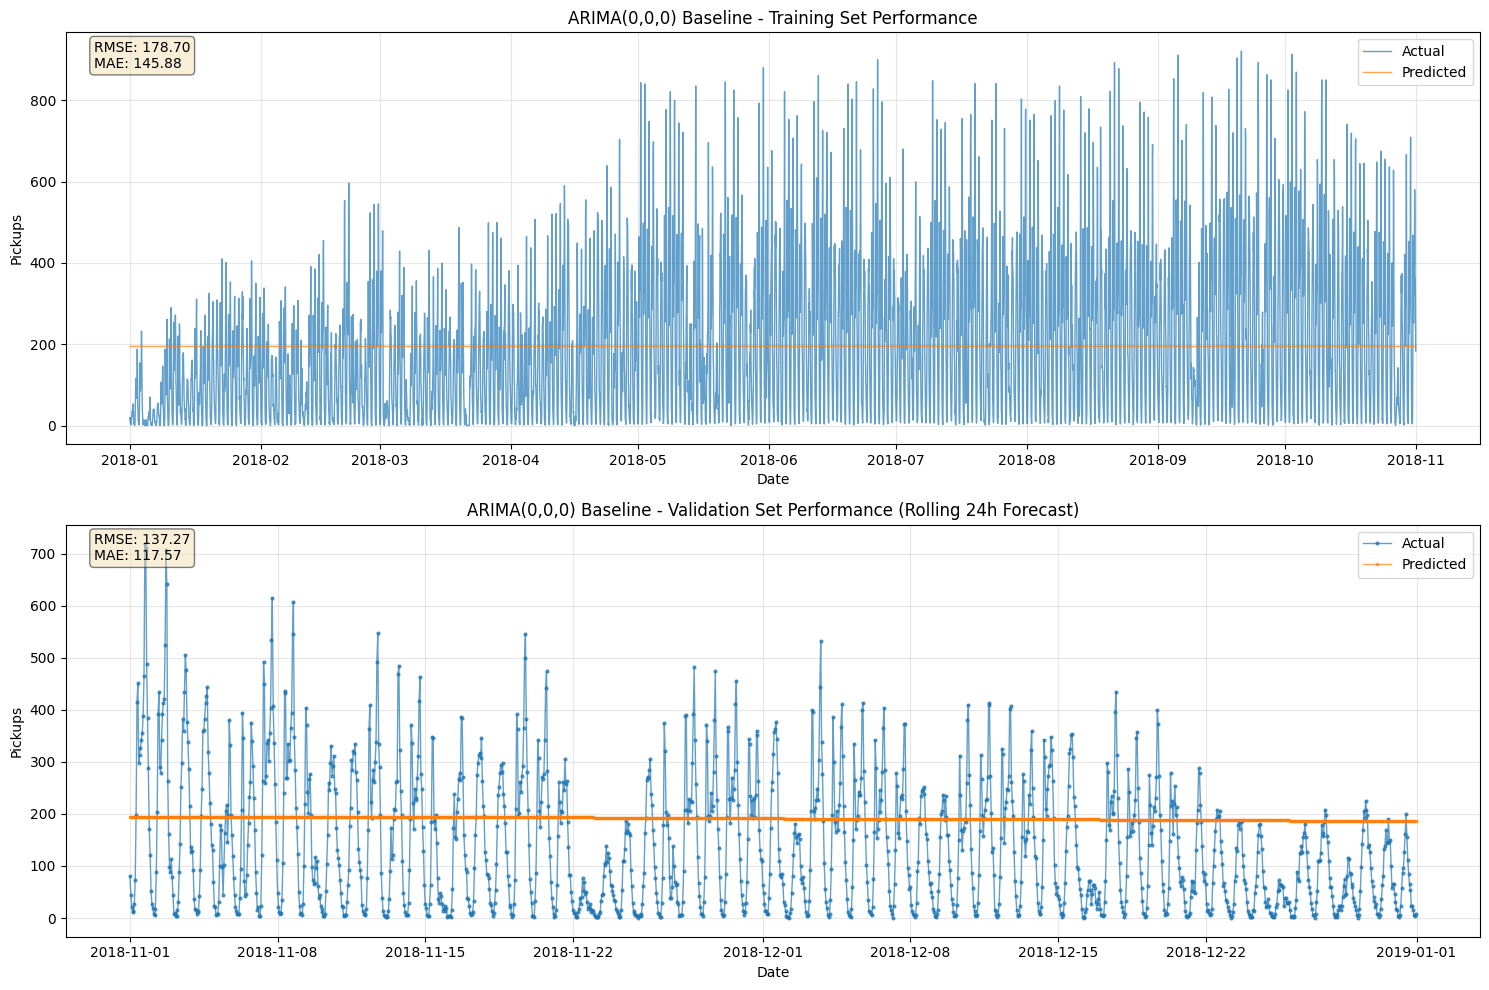

In [20]:
# Evaluate ARIMA(0,0,0) baseline model using helper functions
train_results_baseline, val_results_baseline = evaluate_model(
    model_class=ARIMA,
    train_ts=train_ts,
    val_ts=val_ts,
    order=(0, 0, 0),
    seasonal_order=None,
    enforce_invertibility=False,
    enforce_stationarity=False,
    model_name='ARIMA(0,0,0) Baseline',
    plot=True
)

## ACF and PACF Analysis

Analyzing autocorrelation and partial autocorrelation to identify potential ARIMA parameters.

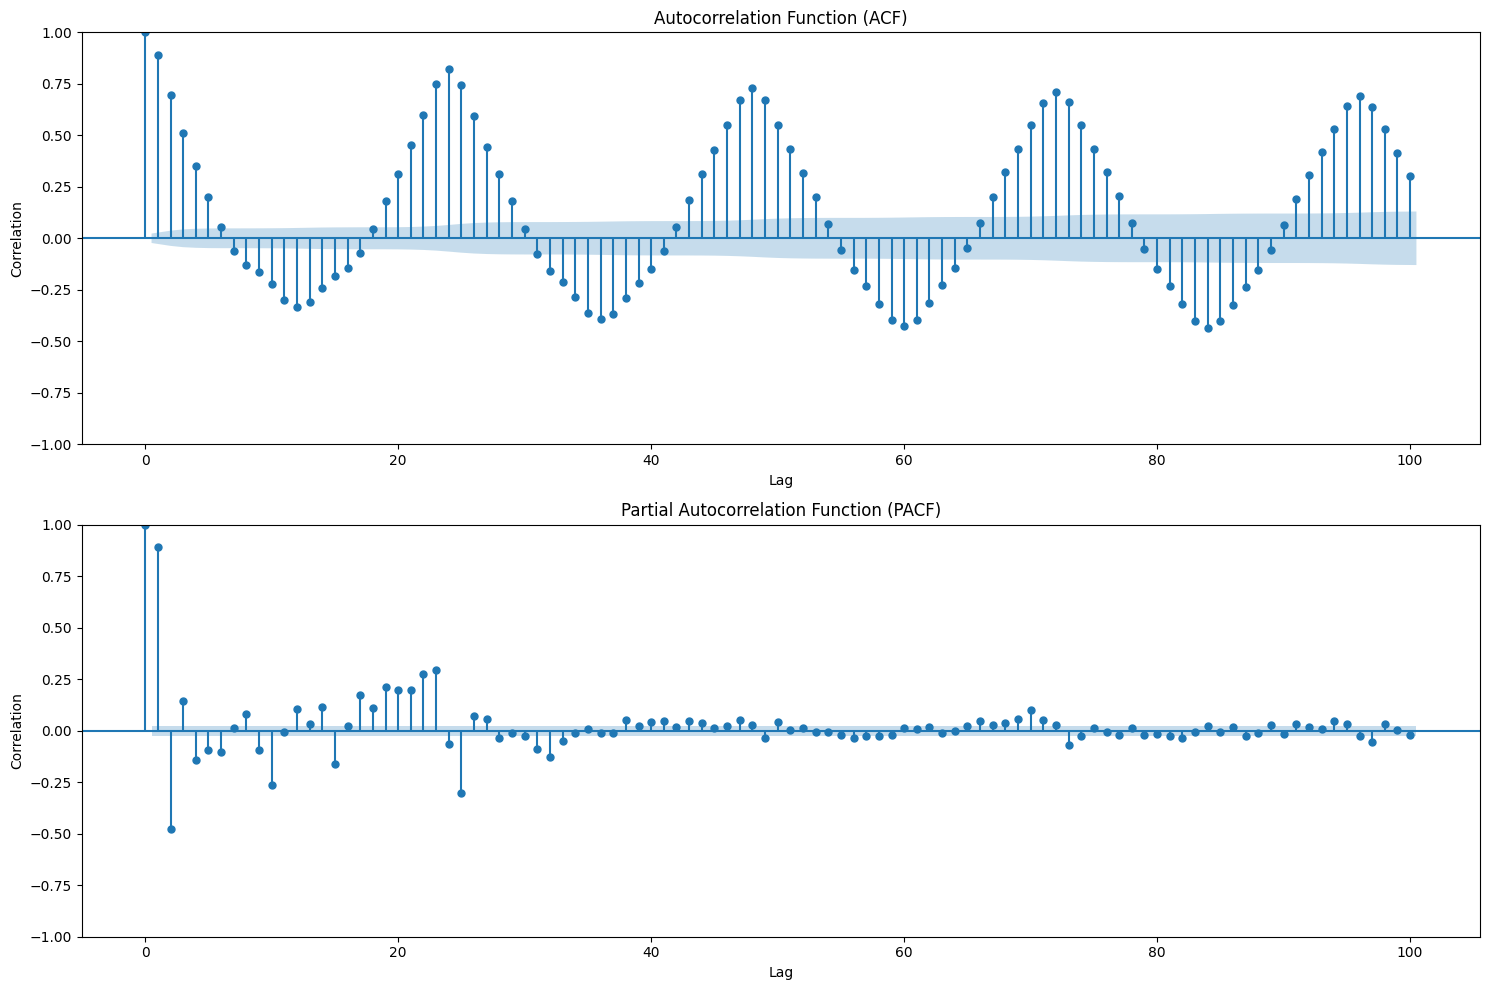

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF (Autocorrelation Function)
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_acf(train_ts, lags=100, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Correlation')

# Plot PACF (Partial Autocorrelation Function)
plot_pacf(train_ts, lags=100, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.show()

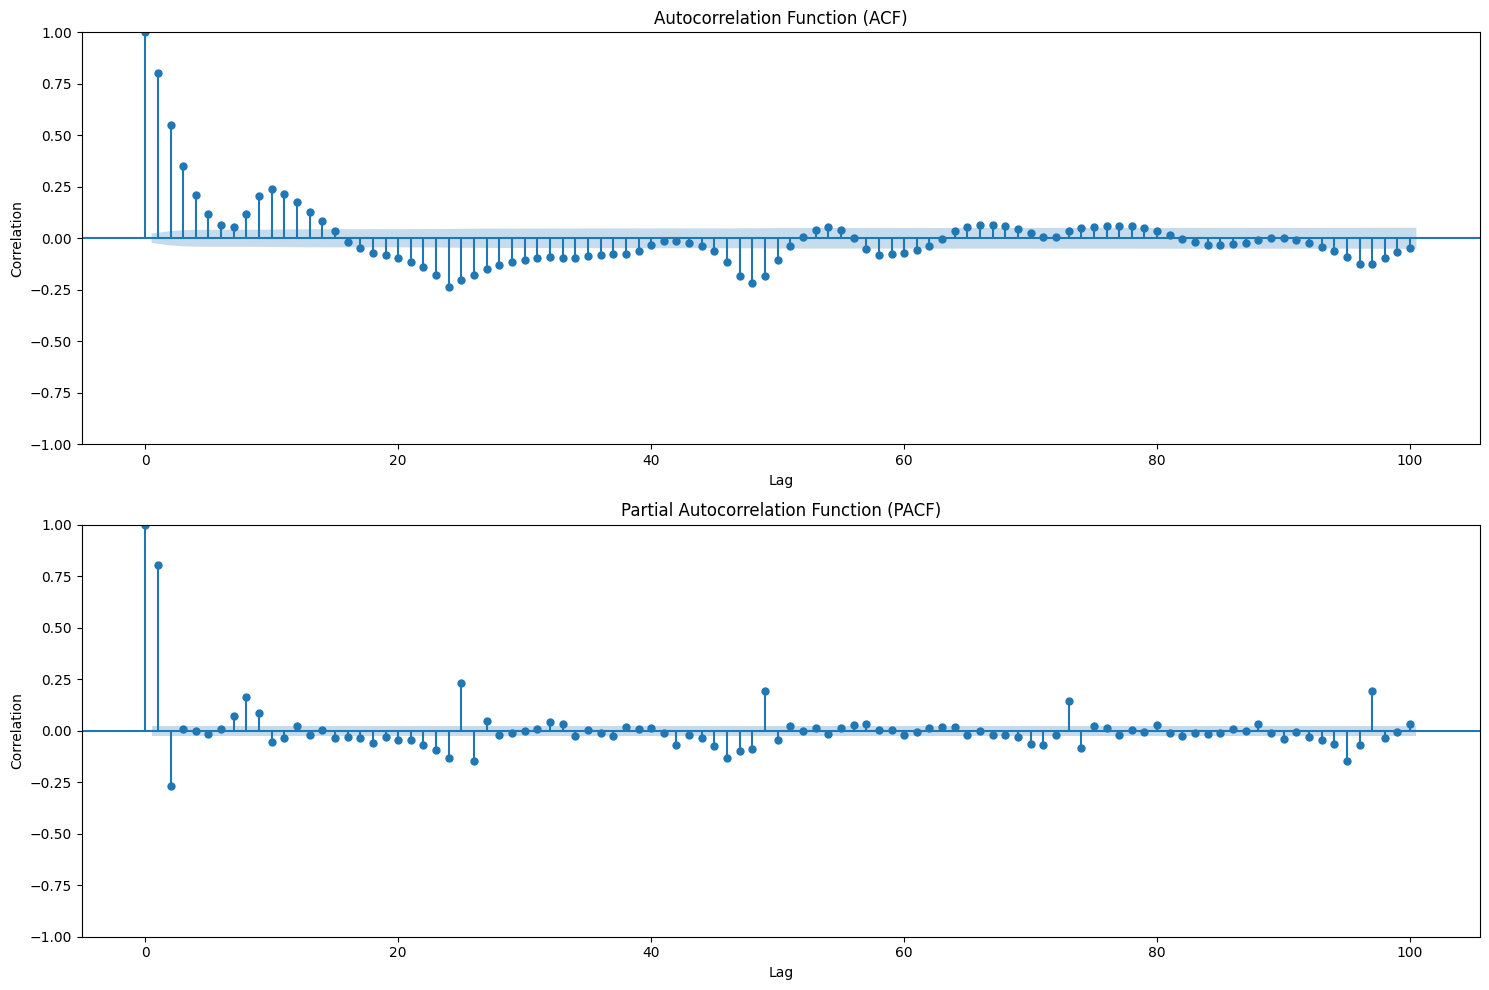

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

train_ts_diff = train_ts.diff(24).dropna()

# Plot ACF (Autocorrelation Function)
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_acf(train_ts_diff, lags=100, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Correlation')

# Plot PACF (Partial Autocorrelation Function)
plot_pacf(train_ts_diff, lags=100, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.show()

## Test SARIMAX



In [23]:
arima = ARIMA(train_ts, order=(0,0,0),
                enforce_invertibility=False, 
                enforce_stationarity=False)
arima_results = arima.fit()

print(arima_results.summary())


sarima = SARIMAX(train_ts, order=(3,1,2), seasonal_order=(0, 1, 1, 24),
                enforce_invertibility=False, enforce_stationarity=False)

sarima_results = sarima.fit()

print(sarima_results.summary())


sarimax = SARIMAX(train_ts, order=(3,1,2), seasonal_order=(0, 1, 1, 24),
                exog=exog_train,
                enforce_invertibility=False, enforce_stationarity=False)

sarimax_results = sarimax.fit()

print(sarimax_results.summary())

results = [arima_results, sarima_results, sarimax_results]


                               SARIMAX Results                                
Dep. Variable:                pickups   No. Observations:                 7296
Model:                          ARIMA   Log Likelihood              -48180.796
Date:                Thu, 04 Dec 2025   AIC                          96365.592
Time:                        10:49:56   BIC                          96379.382
Sample:                    01-01-2018   HQIC                         96370.334
                         - 10-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        194.4425      2.661     73.073      0.000     189.227     199.658
sigma2       3.19e+04    575.730     55.407      0.000    3.08e+04     3.3e+04
Ljung-Box (L1) (Q):                5781.34   Jarque-

Forecasting first day of validation set: 2018-11-01
Time range: 2018-11-01 00:00:00 to 2018-11-01 23:00:00
[<statsmodels.tsa.arima.model.ARIMAResultsWrapper object at 0x167de2bd0>, <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper object at 0x167875400>, <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper object at 0x167e08910>]

Evaluating: ARIMA(0,0,0)

First Day Forecast Performance:
MSE:  48864.82
RMSE: 221.05
MAE:  184.22
MAPE: 241.01%
R²:   -0.1758

Detailed hourly comparison:
               Hour  Actual  Predicted       Error  Abs_Error    Pct_Error
2018-11-01 00:00:00      81 194.442512 -113.442512 113.442512  -140.052483
2018-11-01 01:00:00      45 194.442512 -149.442512 149.442512  -332.094470
2018-11-01 02:00:00      22 194.442512 -172.442512 172.442512  -783.829598
2018-11-01 03:00:00      14 194.442512 -180.442512 180.442512 -1288.875083
2018-11-01 04:00:00      11 194.442512 -183.442512 183.442512 -1667.659196
2018-11-01 05:00:00      27 194.442512 -167.4425

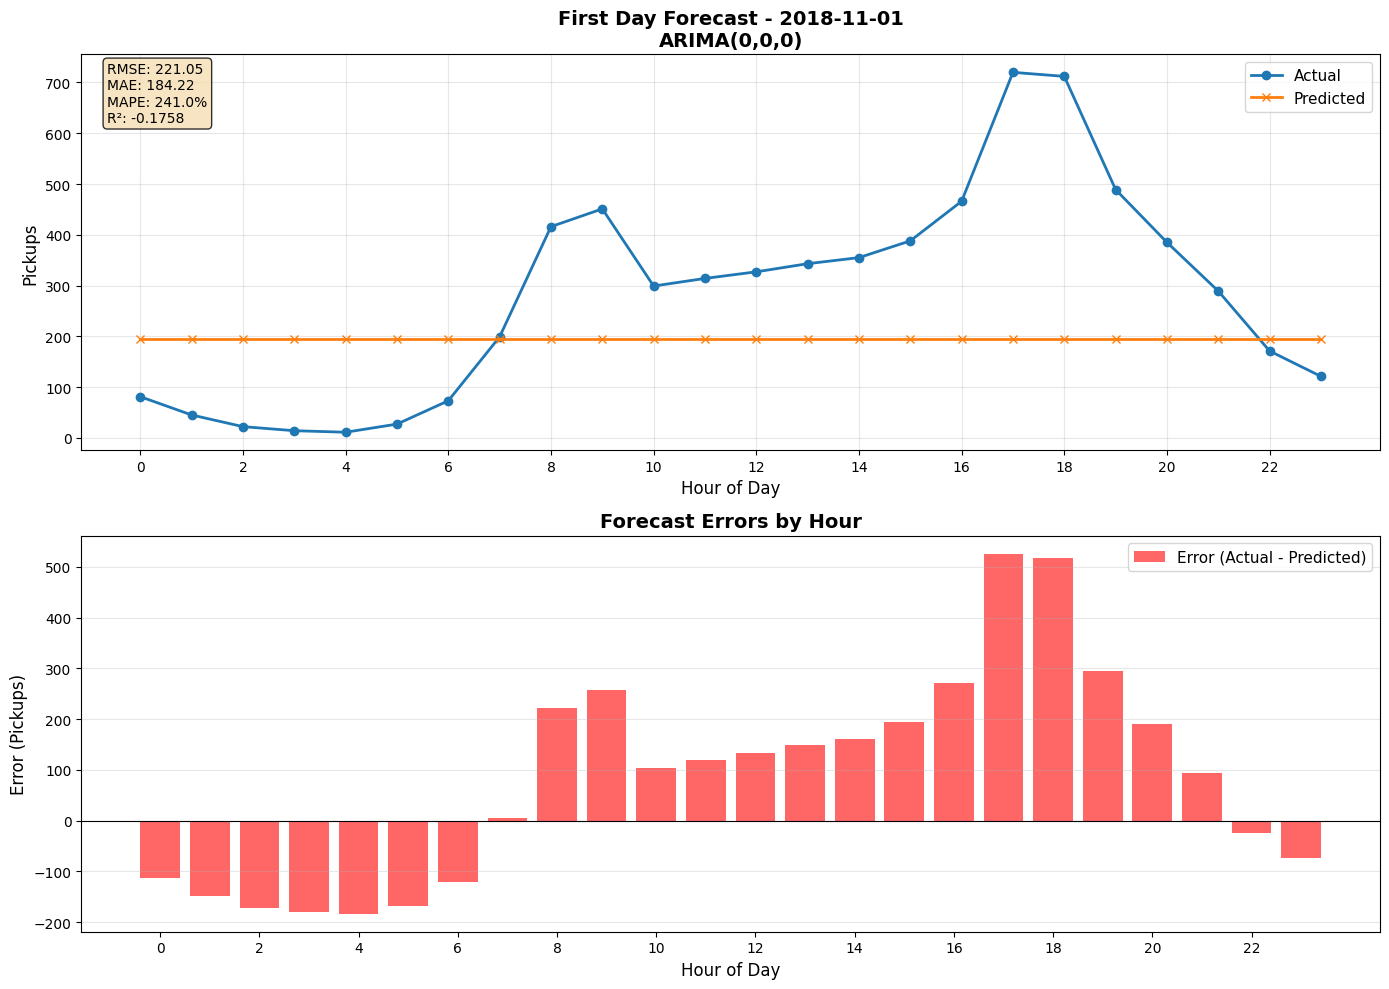


Summary Statistics:
  Average actual pickups: 279.92
  Average predicted pickups: 194.44
  Max overestimate: -183.44 pickups at hour 4
  Max underestimate: 525.56 pickups at hour 17

Evaluating: SARIMA(3,1,2)x(0,1,1,24)

First Day Forecast Performance:
MSE:  3702.31
RMSE: 60.85
MAE:  43.25
MAPE: 18.79%
R²:   0.9109

Detailed hourly comparison:
               Hour  Actual  Predicted      Error  Abs_Error  Pct_Error
2018-11-01 00:00:00      81 110.003867 -29.003867  29.003867 -35.807243
2018-11-01 01:00:00      45  62.863538 -17.863538  17.863538 -39.696750
2018-11-01 02:00:00      22  33.561796 -11.561796  11.561796 -52.553619
2018-11-01 03:00:00      14  17.359541  -3.359541   3.359541 -23.996719
2018-11-01 04:00:00      11   8.316127   2.683873   2.683873  24.398842
2018-11-01 05:00:00      27  19.204636   7.795364   7.795364  28.871720
2018-11-01 06:00:00      73  71.579419   1.420581   1.420581   1.946002
2018-11-01 07:00:00     199 158.224706  40.775294  40.775294  20.490098
2018-

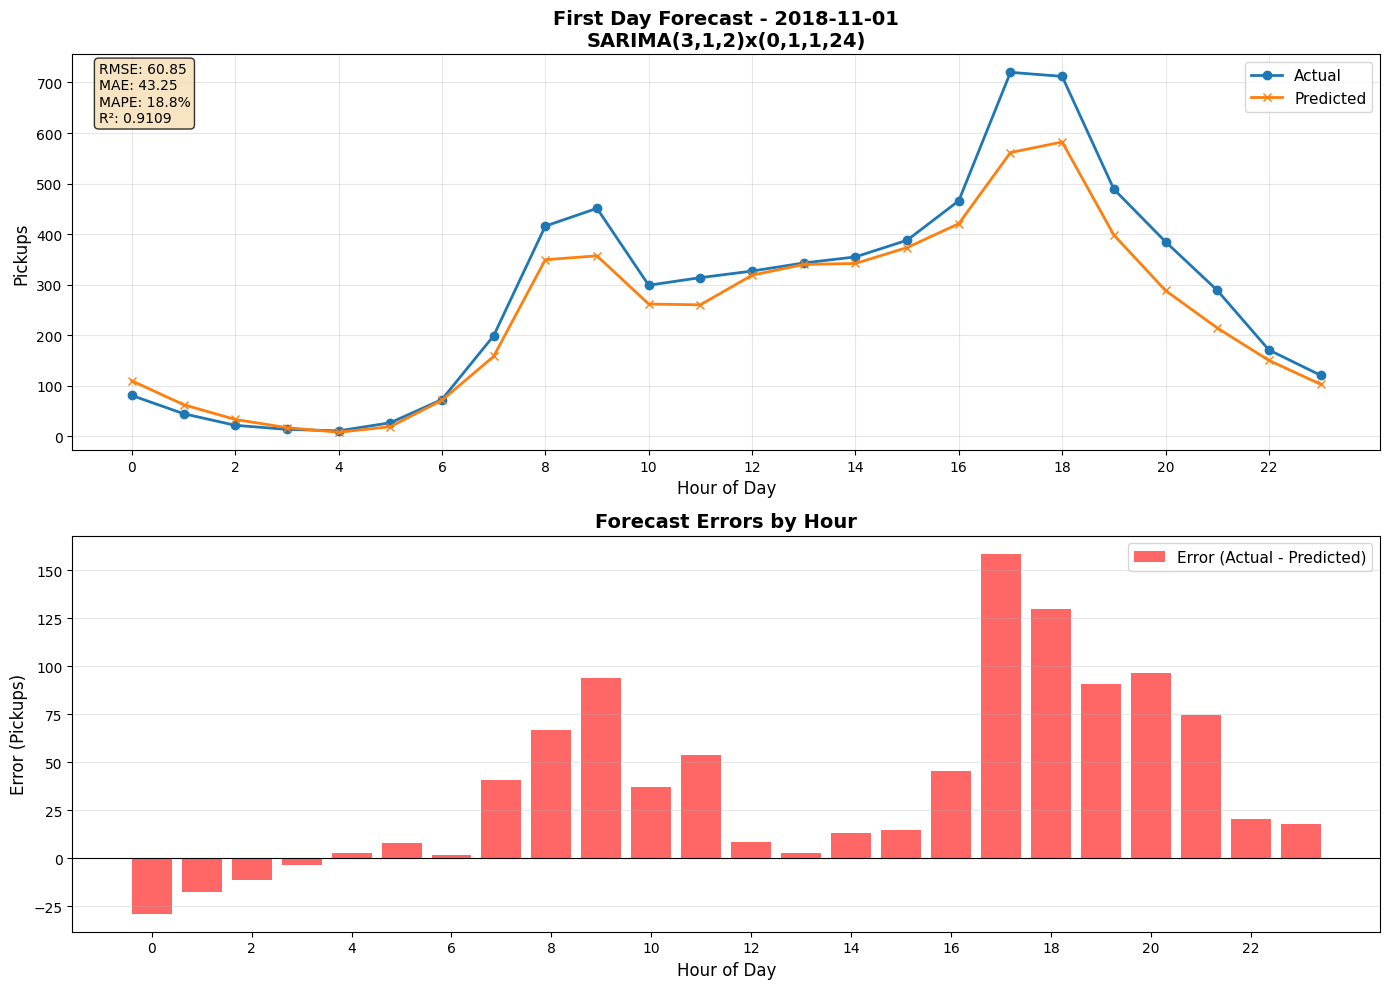


Summary Statistics:
  Average actual pickups: 279.92
  Average predicted pickups: 241.82
  Max overestimate: -29.00 pickups at hour 0
  Max underestimate: 158.67 pickups at hour 17

Evaluating: SARIMAX(3,1,2)x(0,1,1,24) + Exog

First Day Forecast Performance:
MSE:  2301.38
RMSE: 47.97
MAE:  34.72
MAPE: 28.55%
R²:   0.9446

Detailed hourly comparison:
               Hour  Actual  Predicted      Error  Abs_Error   Pct_Error
2018-11-01 00:00:00      81 111.645405 -30.645405  30.645405  -37.833833
2018-11-01 01:00:00      45  69.647304 -24.647304  24.647304  -54.771786
2018-11-01 02:00:00      22  45.014742 -23.014742  23.014742 -104.612463
2018-11-01 03:00:00      14  31.112567 -17.112567  17.112567 -122.232621
2018-11-01 04:00:00      11  25.753921 -14.753921  14.753921 -134.126551
2018-11-01 05:00:00      27  39.254482 -12.254482  12.254482  -45.386970
2018-11-01 06:00:00      73  93.266892 -20.266892  20.266892  -27.762866
2018-11-01 07:00:00     199 180.440958  18.559042  18.559042  

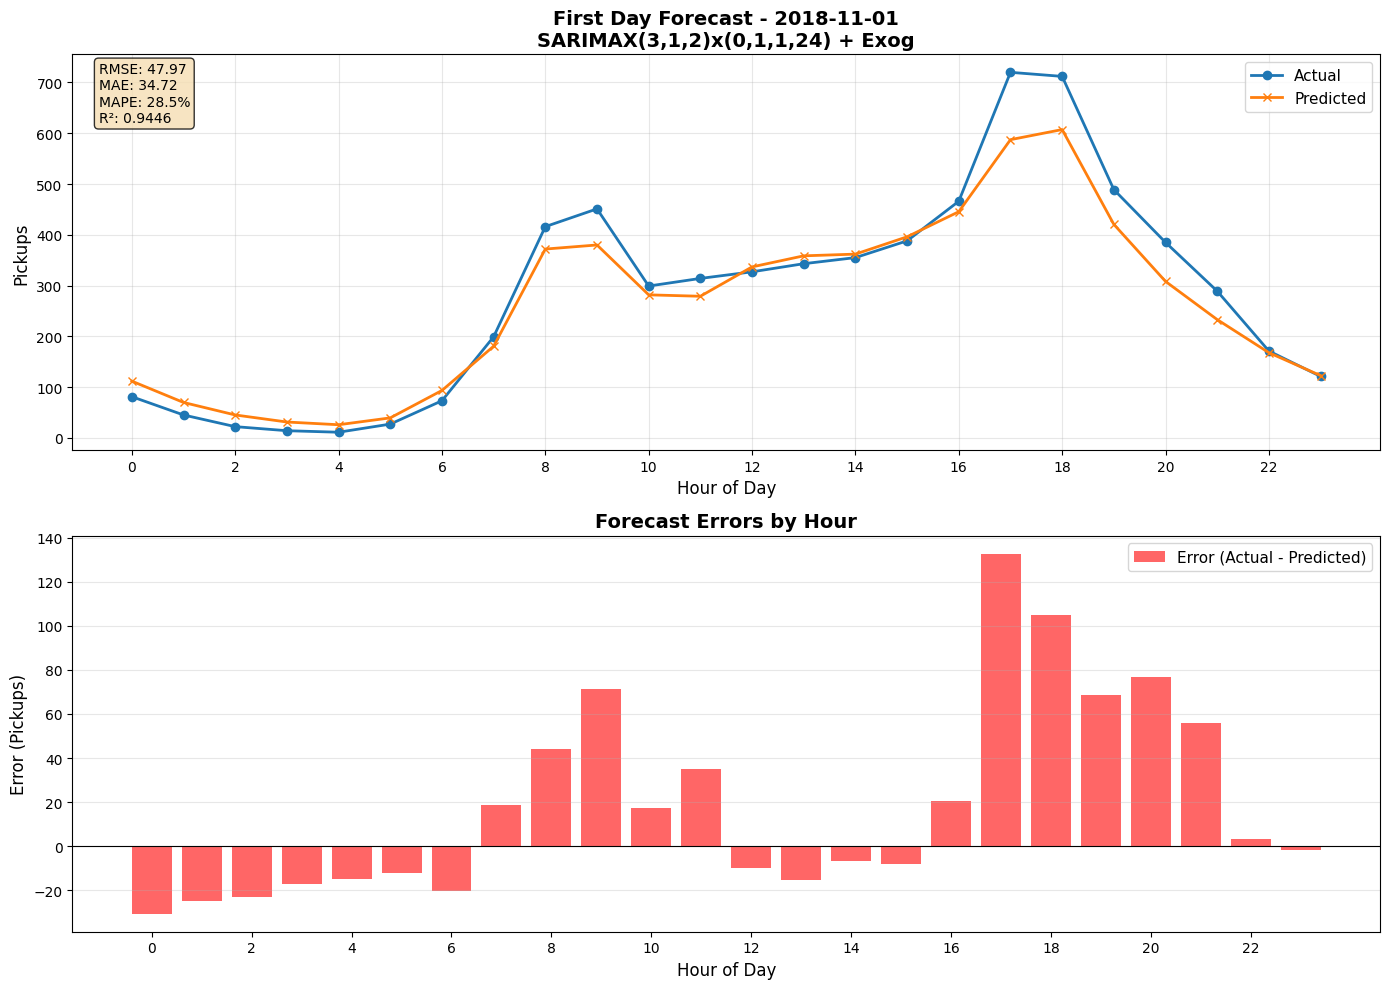


Summary Statistics:
  Average actual pickups: 279.92
  Average predicted pickups: 260.55
  Max overestimate: -30.65 pickups at hour 0
  Max underestimate: 132.66 pickups at hour 17


In [29]:
# Forecast the first day of the validation set (24 hours)
# Get the first day's actual values
first_day = val_ts.iloc[:24]
first_day_exog = exog_val.iloc[:24]
first_day_date = first_day.index[0].date()

print(f"Forecasting first day of validation set: {first_day_date}")
print(f"Time range: {first_day.index[0]} to {first_day.index[-1]}")

import pickle
with open("arima", 'wb') as f:
    pickle.dump(arima_results, f)
with open("sarima", 'wb') as f:
    pickle.dump(sarima_results, f)
with open("sarimax", 'wb') as f:
    pickle.dump(sarimax_results, f)

print(results)

model_names = ['ARIMA(0,0,0)', 'SARIMA(3,1,2)x(0,1,1,24)', 'SARIMAX(3,1,2)x(0,1,1,24) + Exog']

for idx, result in enumerate(results):
    model_name = model_names[idx]
    print(f"\n{'='*70}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*70}")
    
    # Use the fitted model to forecast 24 hours
    # Only SARIMAX (last model) needs exogenous features
    if idx == 2:  # SARIMAX with exog
        forecast_first_day = result.forecast(steps=24, exog=first_day_exog)
    else:  # ARIMA and SARIMA without exog
        forecast_first_day = result.forecast(steps=24)

    # Calculate errors
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    actual = first_day.values
    predicted = forecast_first_day.values

    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)

    print(f"\nFirst Day Forecast Performance:")
    print(f"{'='*50}")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²:   {r2:.4f}")
    print(f"{'='*50}")

    # Create a detailed comparison table
    comparison_df = pd.DataFrame({
        'Hour': first_day.index,
        'Actual': actual,
        'Predicted': predicted,
        'Error': actual - predicted,
        'Abs_Error': np.abs(actual - predicted),
        'Pct_Error': ((actual - predicted) / actual * 100)
    })

    print(f"\nDetailed hourly comparison:")
    print(comparison_df.to_string(index=False))

    # Plot actual vs predicted for the first day
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Actual vs Predicted
    hours = range(24)
    axes[0].plot(hours, actual, marker='o', label='Actual', linewidth=2, markersize=6)
    axes[0].plot(hours, predicted, marker='x', label='Predicted', linewidth=2, markersize=6)
    axes[0].set_title(f'First Day Forecast - {first_day_date}\n{model_name}', 
                  fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Hour of Day', fontsize=12)
    axes[0].set_ylabel('Pickups', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(range(0, 24, 2))
    # Add metrics text box
    metrics_text = f'RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE: {mape:.1f}%\nR²: {r2:.4f}'
    axes[0].text(0.02, 0.98, metrics_text,
                transform=axes[0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                fontsize=10)

    # Plot 2: Errors
    axes[1].bar(hours, actual - predicted, color='red', alpha=0.6, label='Error (Actual - Predicted)')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    axes[1].set_title('Forecast Errors by Hour', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Hour of Day', fontsize=12)
    axes[1].set_ylabel('Error (Pickups)', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].set_xticks(range(0, 24, 2))

    plt.tight_layout()
    plt.show()

    print(f"\nSummary Statistics:")
    print(f"  Average actual pickups: {actual.mean():.2f}")
    print(f"  Average predicted pickups: {predicted.mean():.2f}")

    print(f"  Max overestimate: {(actual - predicted).min():.2f} pickups at hour {(actual - predicted).argmin()}")
    print(f"  Max underestimate: {(actual - predicted).max():.2f} pickups at hour {(actual - predicted).argmax()}")

## Extended Validation: All Days Forecast

Testing the model's forecasting capability across the entire validation period (Nov-Dec 2018) by forecasting all 61 days.

Forecasting all days in validation period: Nov-Dec 2018
Validation period: 2018-11-01 00:00:00 to 2018-12-31 23:00:00
Total hours: 1464
Total days: 61.0

Evaluating: ARIMA(0,0,0)
  Day 1/61 (2018-11-01): RMSE=221.05, MAE=184.22
  Day 2/61 (2018-11-02): RMSE=211.37, MAE=176.80
  Day 3/61 (2018-11-03): RMSE=162.90, MAE=145.79
  Day 4/61 (2018-11-04): RMSE=149.52, MAE=132.91
  Day 5/61 (2018-11-05): RMSE=119.37, MAE=98.55
  Day 6/61 (2018-11-06): RMSE=132.75, MAE=117.99
  Day 7/61 (2018-11-07): RMSE=188.48, MAE=163.76
  Day 8/61 (2018-11-08): RMSE=178.16, MAE=151.89
  Day 9/61 (2018-11-09): RMSE=129.69, MAE=116.11
  Day 10/61 (2018-11-10): RMSE=122.47, MAE=110.44
  Day 11/61 (2018-11-11): RMSE=128.71, MAE=116.74
  Day 12/61 (2018-11-12): RMSE=160.34, MAE=136.80
  Day 13/61 (2018-11-13): RMSE=146.31, MAE=120.90
  Day 14/61 (2018-11-14): RMSE=135.24, MAE=113.46
  Day 15/61 (2018-11-15): RMSE=148.14, MAE=134.54
  Day 16/61 (2018-11-16): RMSE=128.59, MAE=110.07
  Day 17/61 (2018-11-17): RMSE=

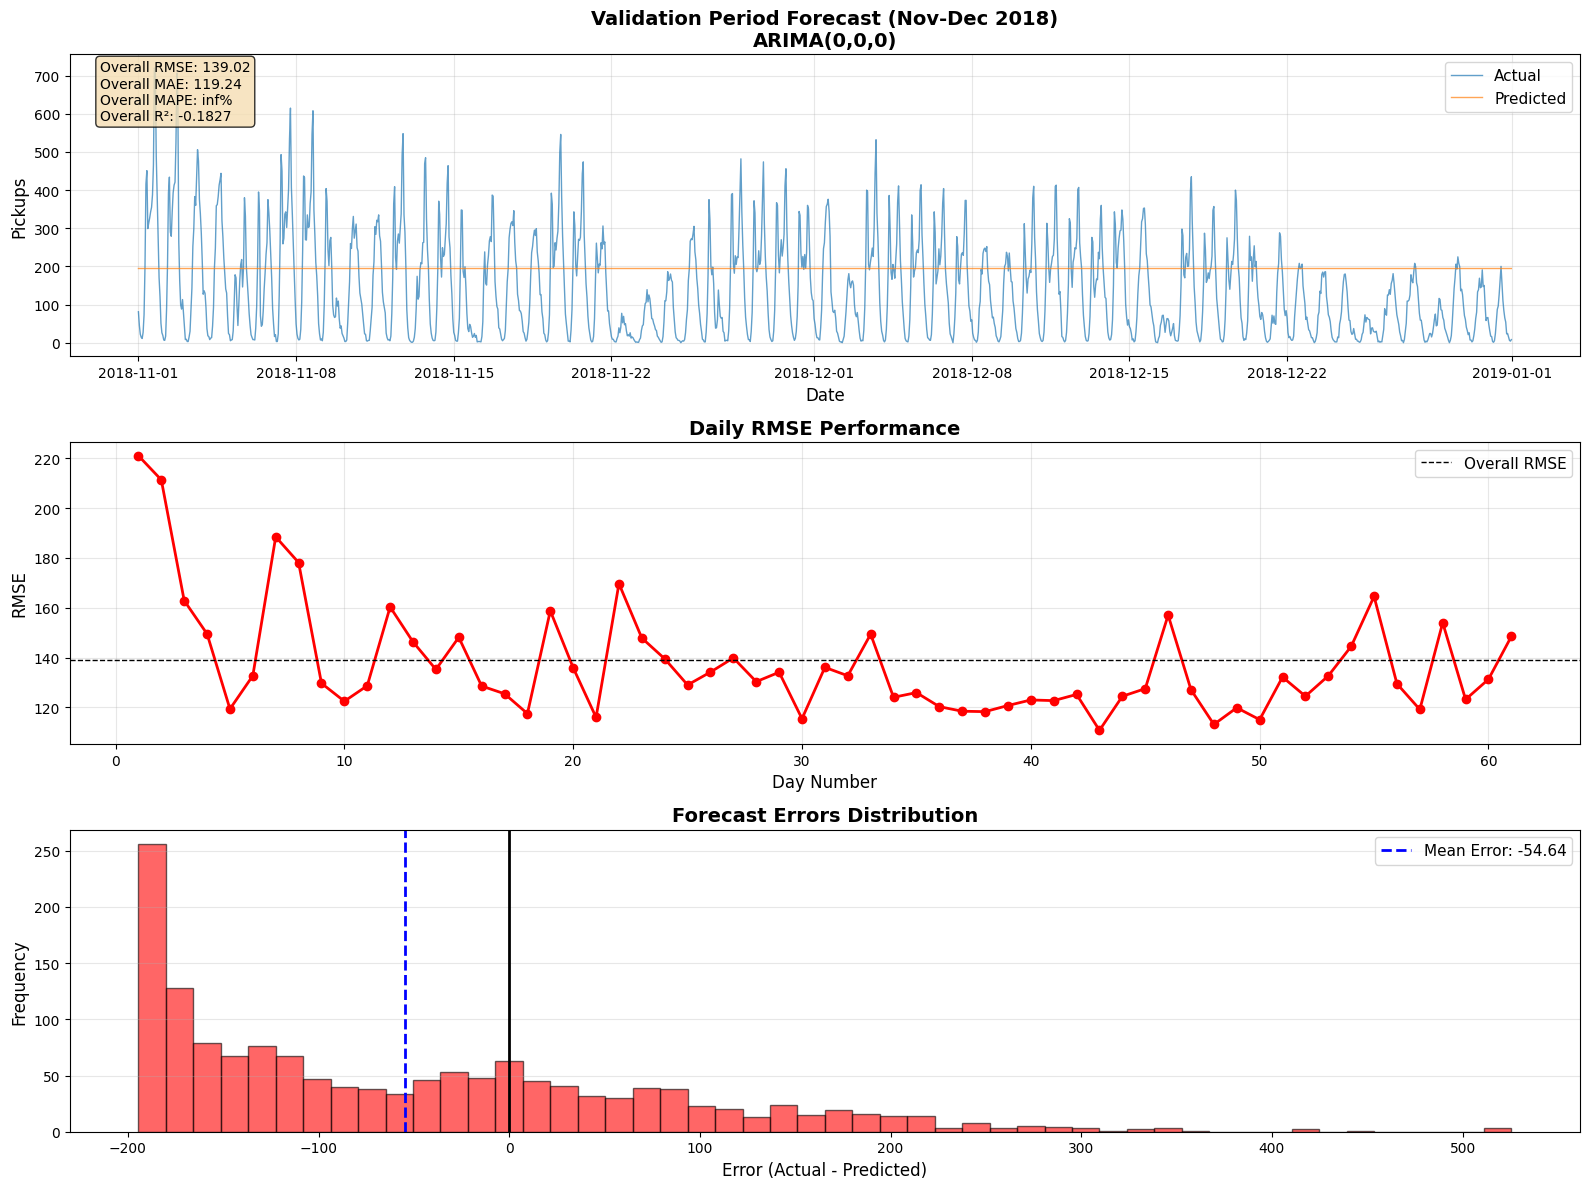


Error Statistics:
  Mean Error: -54.64
  Std Error: 127.83
  Min Error (max overestimate): -194.44
  Max Error (max underestimate): 525.56

Evaluating: SARIMA(3,1,2)x(0,1,1,24)
  Day 1/61 (2018-11-01): RMSE=60.85, MAE=43.25
  Day 2/61 (2018-11-02): RMSE=69.00, MAE=54.54
  Day 3/61 (2018-11-03): RMSE=110.15, MAE=79.94
  Day 4/61 (2018-11-04): RMSE=117.73, MAE=81.83
  Day 5/61 (2018-11-05): RMSE=145.95, MAE=120.49
  Day 6/61 (2018-11-06): RMSE=142.78, MAE=102.36
  Day 7/61 (2018-11-07): RMSE=49.78, MAE=35.59
  Day 8/61 (2018-11-08): RMSE=38.83, MAE=29.93
  Day 9/61 (2018-11-09): RMSE=192.64, MAE=125.23
  Day 10/61 (2018-11-10): RMSE=136.72, MAE=95.07
  Day 11/61 (2018-11-11): RMSE=138.38, MAE=99.78
  Day 12/61 (2018-11-12): RMSE=51.19, MAE=42.66
  Day 13/61 (2018-11-13): RMSE=110.61, MAE=92.28
  Day 14/61 (2018-11-14): RMSE=73.53, MAE=60.07
  Day 15/61 (2018-11-15): RMSE=227.88, MAE=158.83
  Day 16/61 (2018-11-16): RMSE=106.95, MAE=93.03
  Day 17/61 (2018-11-17): RMSE=137.13, MAE=95.18


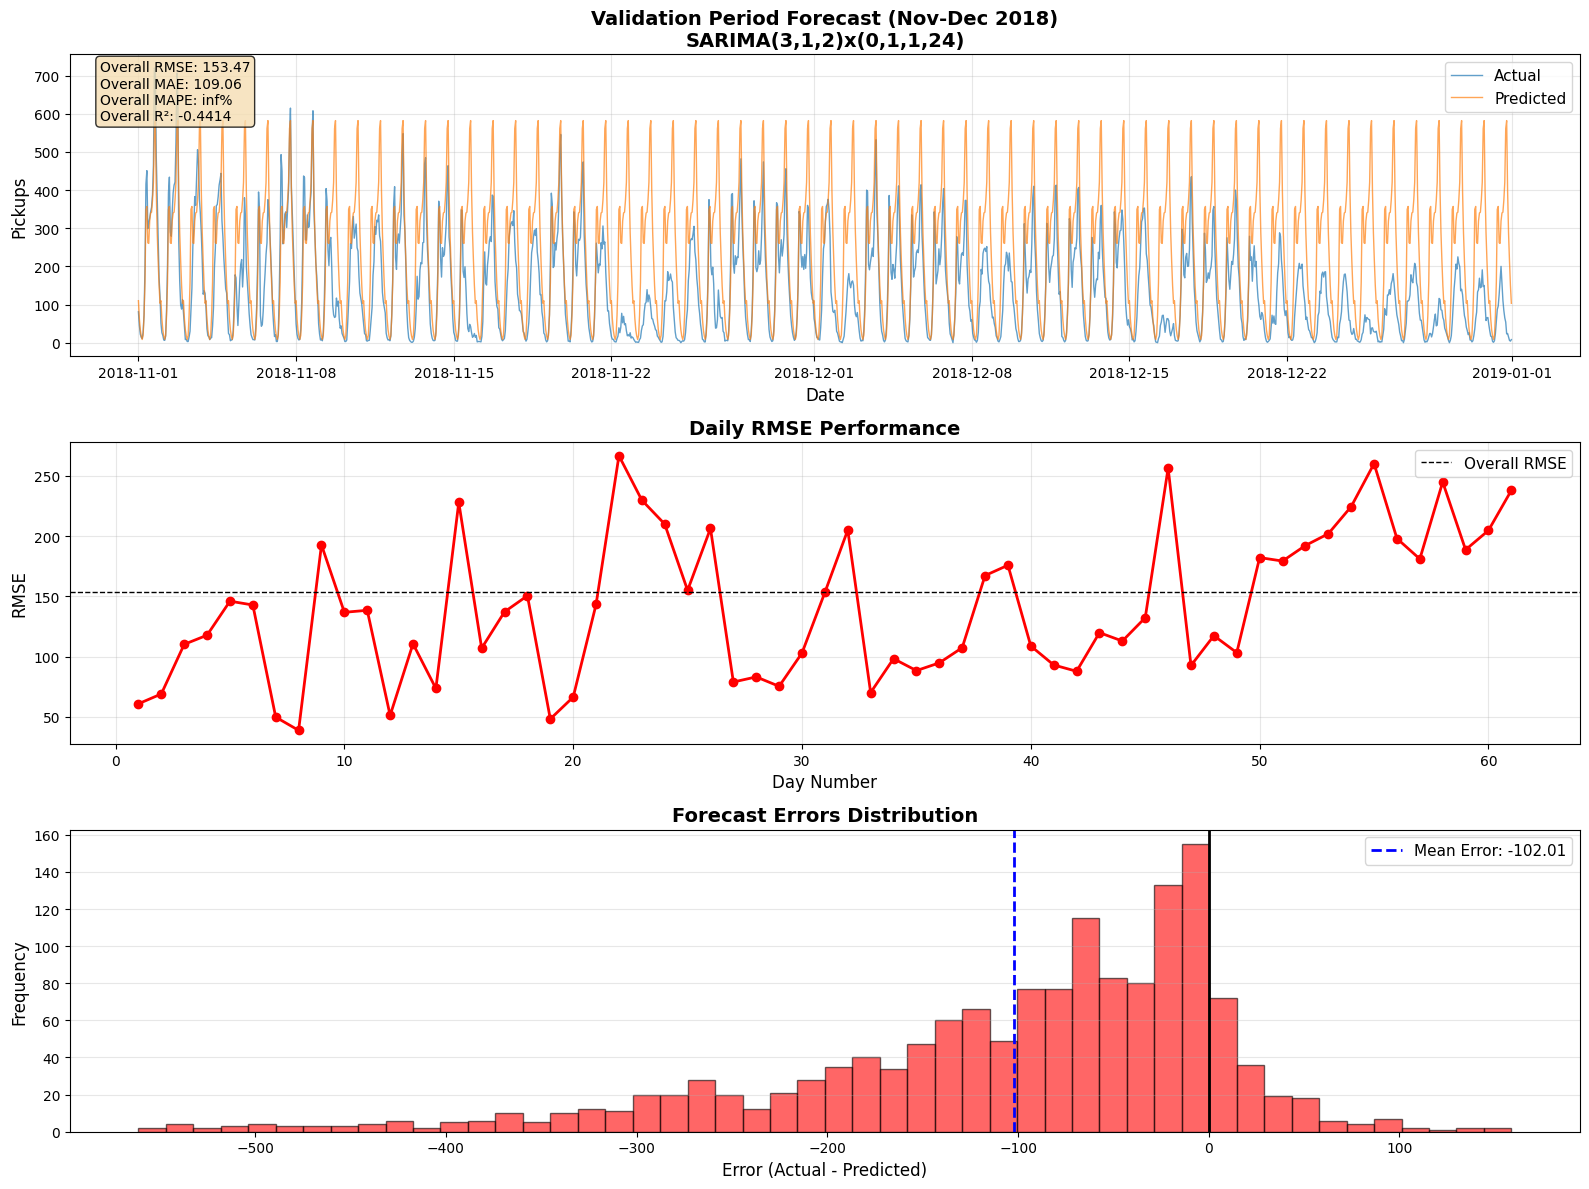


Error Statistics:
  Mean Error: -102.01
  Std Error: 114.66
  Min Error (max overestimate): -561.26
  Max Error (max underestimate): 158.67

Evaluating: SARIMAX(3,1,2)x(0,1,1,24) + Exog
  Day 1/61 (2018-11-01): RMSE=47.97, MAE=34.72
  Day 2/61 (2018-11-02): RMSE=67.38, MAE=49.59
  Day 3/61 (2018-11-03): RMSE=119.92, MAE=89.93
  Day 4/61 (2018-11-04): RMSE=120.97, MAE=84.25
  Day 5/61 (2018-11-05): RMSE=151.50, MAE=123.26
  Day 6/61 (2018-11-06): RMSE=158.88, MAE=114.81
  Day 7/61 (2018-11-07): RMSE=44.52, MAE=34.44
  Day 8/61 (2018-11-08): RMSE=35.84, MAE=28.64
  Day 9/61 (2018-11-09): RMSE=192.26, MAE=123.47
  Day 10/61 (2018-11-10): RMSE=136.38, MAE=96.61
  Day 11/61 (2018-11-11): RMSE=134.50, MAE=93.25
  Day 12/61 (2018-11-12): RMSE=55.84, MAE=46.78
  Day 13/61 (2018-11-13): RMSE=114.59, MAE=93.80
  Day 14/61 (2018-11-14): RMSE=65.81, MAE=51.92
  Day 15/61 (2018-11-15): RMSE=215.32, MAE=146.10
  Day 16/61 (2018-11-16): RMSE=101.38, MAE=85.30
  Day 17/61 (2018-11-17): RMSE=135.12, M

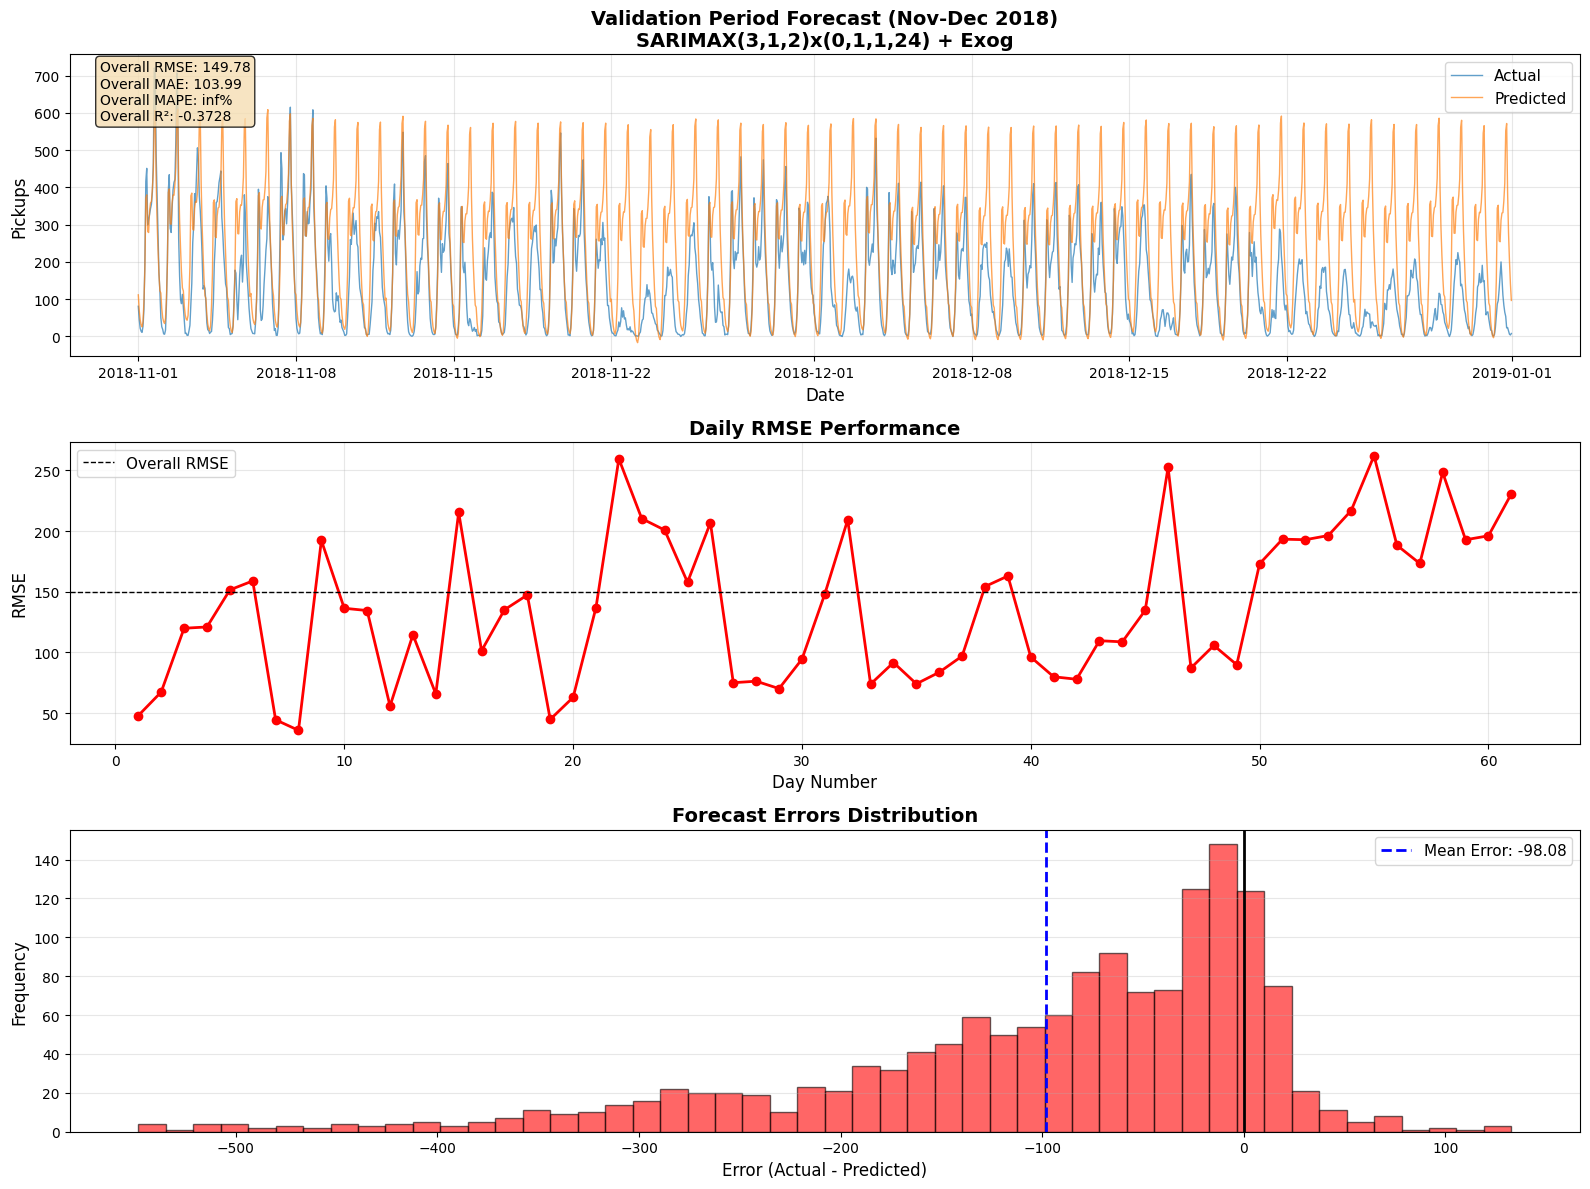


Error Statistics:
  Mean Error: -98.08
  Std Error: 113.19
  Min Error (max overestimate): -548.33
  Max Error (max underestimate): 132.66


In [31]:
# Forecast all days in validation period (Nov-Dec) using 24-hour rolling forecasts
# This tests the model's forecasting capability across the entire validation set

print(f"Forecasting all days in validation period: Nov-Dec 2018")
print(f"Validation period: {val_ts.index[0]} to {val_ts.index[-1]}")
print(f"Total hours: {len(val_ts)}")
print(f"Total days: {len(val_ts) / 24:.1f}")

model_names = ['ARIMA(0,0,0)', 'SARIMA(3,1,2)x(0,1,1,24)', 'SARIMAX(3,1,2)x(0,1,1,24) + Exog']

for idx, model in enumerate(results):
    model_name = model_names[idx]
    
    print(f"\n{'='*70}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*70}")
    
    # Store all predictions and metrics per day
    all_predictions = []
    all_actuals = []
    daily_metrics = []

    # Forecast 24 hours at a time (one day at a time)
    num_days = int(np.ceil(len(val_ts) / 24))

    for day_num in range(num_days):
        # Get the day's data
        start_idx = day_num * 24
        end_idx = min(start_idx + 24, len(val_ts))
        
        day_actual = val_ts.iloc[start_idx:end_idx]
        day_exog = exog_val.iloc[start_idx:end_idx]
        day_date = day_actual.index[0].date()
        
        # Forecast this day (24 hours or less for the last day)
        steps = end_idx - start_idx
        
        # Only SARIMAX (idx==2) needs exogenous features
        if idx == 2:
            day_forecast = model.forecast(steps=steps, exog=day_exog)
        else:
            day_forecast = model.forecast(steps=steps)
        
        # Store predictions and actuals
        all_predictions.extend(day_forecast.values)
        all_actuals.extend(day_actual.values)
        
        # Calculate metrics for this day
        day_mse = mean_squared_error(day_actual.values, day_forecast.values)
        day_rmse = np.sqrt(day_mse)
        day_mae = mean_absolute_error(day_actual.values, day_forecast.values)
        day_mape = np.mean(np.abs((day_actual.values - day_forecast.values) / day_actual.values)) * 100
        
        daily_metrics.append({
            'date': day_date,
            'day_num': day_num + 1,
            'hours': steps,
            'rmse': day_rmse,
            'mae': day_mae,
            'mape': day_mape,
            'mean_actual': day_actual.mean(),
            'mean_predicted': day_forecast.mean()
        })
        
        print(f"  Day {day_num + 1}/{num_days} ({day_date}): RMSE={day_rmse:.2f}, MAE={day_mae:.2f}")

    # Convert to arrays
    all_predictions = np.array(all_predictions)
    all_actuals = np.array(all_actuals)

    # Calculate overall metrics across all validation days
    overall_mse = mean_squared_error(all_actuals, all_predictions)
    overall_rmse = np.sqrt(overall_mse)
    overall_mae = mean_absolute_error(all_actuals, all_predictions)
    overall_mape = np.mean(np.abs((all_actuals - all_predictions) / all_actuals)) * 100
    overall_r2 = r2_score(all_actuals, all_predictions)

    print(f"\n{'='*70}")
    print(f"OVERALL VALIDATION PERFORMANCE (All Nov-Dec Days)")
    print(f"{'='*70}")
    print(f"MSE:  {overall_mse:.2f}")
    print(f"RMSE: {overall_rmse:.2f}")
    print(f"MAE:  {overall_mae:.2f}")
    print(f"MAPE: {overall_mape:.2f}%")
    print(f"R²:   {overall_r2:.4f}")
    print(f"{'='*70}")

    # Create daily metrics dataframe
    daily_metrics_df = pd.DataFrame(daily_metrics)

    print(f"\nDaily Performance Summary:")
    print(daily_metrics_df.to_string(index=False))

    print(f"\nDaily Metrics Statistics:")
    print(f"  Average Daily RMSE: {daily_metrics_df['rmse'].mean():.2f} ± {daily_metrics_df['rmse'].std():.2f}")
    print(f"  Average Daily MAE:  {daily_metrics_df['mae'].mean():.2f} ± {daily_metrics_df['mae'].std():.2f}")
    print(f"  Best Day (lowest RMSE): Day {daily_metrics_df.loc[daily_metrics_df['rmse'].idxmin(), 'day_num']} ({daily_metrics_df.loc[daily_metrics_df['rmse'].idxmin(), 'date']}), RMSE={daily_metrics_df['rmse'].min():.2f}")
    print(f"  Worst Day (highest RMSE): Day {daily_metrics_df.loc[daily_metrics_df['rmse'].idxmax(), 'day_num']} ({daily_metrics_df.loc[daily_metrics_df['rmse'].idxmax(), 'date']}), RMSE={daily_metrics_df['rmse'].max():.2f}")

    # Plot overall predictions vs actuals
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))

    # Plot 1: Full validation period - Actual vs Predicted
    axes[0].plot(val_ts.index, all_actuals, label='Actual', alpha=0.7, linewidth=1)
    axes[0].plot(val_ts.index, all_predictions, label='Predicted', alpha=0.7, linewidth=1)
    axes[0].set_title(f'Validation Period Forecast (Nov-Dec 2018)\n{model_name}', 
                    fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Date', fontsize=12)
    axes[0].set_ylabel('Pickups', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    metrics_text = f'Overall RMSE: {overall_rmse:.2f}\nOverall MAE: {overall_mae:.2f}\nOverall MAPE: {overall_mape:.1f}%\nOverall R²: {overall_r2:.4f}'
    axes[0].text(0.02, 0.98, metrics_text,
                transform=axes[0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                fontsize=10)

    # Plot 2: Daily RMSE over time
    axes[1].plot(daily_metrics_df['day_num'], daily_metrics_df['rmse'], 
                marker='o', linewidth=2, markersize=6, color='red')
    axes[1].axhline(y=overall_rmse, color='black', linestyle='--', linewidth=1, label='Overall RMSE')
    axes[1].set_title('Daily RMSE Performance', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Day Number', fontsize=12)
    axes[1].set_ylabel('RMSE', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Errors distribution
    errors = all_actuals - all_predictions
    axes[2].hist(errors, bins=50, color='red', alpha=0.6, edgecolor='black')
    axes[2].axvline(x=0, color='black', linestyle='-', linewidth=2)
    axes[2].axvline(x=errors.mean(), color='blue', linestyle='--', linewidth=2, 
                    label=f'Mean Error: {errors.mean():.2f}')
    axes[2].set_title('Forecast Errors Distribution', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Error (Actual - Predicted)', fontsize=12)
    axes[2].set_ylabel('Frequency', fontsize=12)
    axes[2].legend(fontsize=11)
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"\nError Statistics:")
    print(f"  Mean Error: {errors.mean():.2f}")
    print(f"  Std Error: {errors.std():.2f}")

    print(f"  Min Error (max overestimate): {errors.min():.2f}")
    print(f"  Max Error (max underestimate): {errors.max():.2f}")